# Reto 04
### Microred eléctrica

**Estrategia**
- Métrica maximizada: **Hypervolume (HV)**
- Cada configuración se ejecuta `N_RUNS` veces con semillas distintas; se reporta la **mediana** del HV.
- Hiperparámetros buscados: `eta_c` , `crossover_prob` (SBX), `eta_m` (PM).

## 1. Imports y configuración

In [2]:
import os, random, time, json, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import optuna

from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.algorithm.multiobjective.spea2 import SPEA2
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.core.quality_indicator import HyperVolume

warnings.filterwarnings('ignore')
logging.getLogger('jmetal').setLevel(logging.ERROR)

### CONFIGURACIÓN GLOBAL

In [3]:
BASE_SEED = 42  # Semilla base para reproducibilidad

# Rutas
DATA_DIR1   = '../data/raw'  
DATA_DIR2   = '../data/processed' 
DATA_DIR3   = '../data/results'   
OUTPUT_DIR = '/resultados'

# --- Horizonte de optimización --------------------------------------------
T_HOURS    = 168    # ventana representativa (1 semana) -> 504 variables
START_HOUR = 0      # hora de inicio dentro del año (0 .. 8759 - T_HOURS)
PRED_YEAR  = 2020   # año de las predicciones de potencia (2017-2020 disponibles)

# --- Parámetros de la batería ---------------------------------------------
BATTERY_HOURS   = 3.0
BATTERY_EFF_C   = 0.95
BATTERY_EFF_D   = 0.95
BATTERY_SOC_MIN = 0.10
BATTERY_SOC_MAX = 0.90
BATTERY_SOC_INI = 0.50

# --- Presupuesto evolutivo ------------------------------------------------
POPULATION_SIZE    = 200
GENERATIONS_SEARCH = 150   # para cada trial de Optuna (~30% del presupuesto final)
GENERATIONS_FINAL  = 500   # para el resultado que se analiza y publica

# --- Optuna ---------------------------------------------------------------
N_TRIALS      = 20
# 3 semillas
N_RUNS_SEARCH = 3
ALGORITHMS    = ['NSGAII', 'SPEA2']

# Espacio de búsqueda
SEARCH_SPACE = {
    'eta_c'          : (5.0, 30.0),   # índice distribución SBX  (5=explorador, 30=explotador)
    'eta_m'          : (5.0, 30.0),   # índice distribución PM
    'crossover_prob' : (0.7, 1.0),    # probabilidad de cruce SBX (literatura: >=0.7)
}

evals_search = POPULATION_SIZE * GENERATIONS_SEARCH * N_RUNS_SEARCH * N_TRIALS * len(ALGORITHMS)
evals_final  = POPULATION_SIZE * GENERATIONS_FINAL  * len(ALGORITHMS)
print('Configuración cargada.')
print(f'  Ventana            : {T_HOURS} h  (desde la hora {START_HOUR})  -> {3*T_HOURS} variables')
print(f'  Año predicciones   : {PRED_YEAR}')
print(f'  Batería            : {BATTERY_HOURS} h de demanda media | SOC [{BATTERY_SOC_MIN:.0%}, {BATTERY_SOC_MAX:.0%}]')
print(f'  Población (fija)   : {POPULATION_SIZE}')
print(f'  Generaciones search: {GENERATIONS_SEARCH}  | Generaciones final: {GENERATIONS_FINAL}')
print(f'  Runs/trial (search): {N_RUNS_SEARCH}  | Trials Optuna/algo: {N_TRIALS}')
print(f'  Evaluaciones Optuna (total): {evals_search:,}')
print(f'  Evaluaciones ejecución final (total): {evals_final:,}')

Configuración cargada.
  Ventana            : 168 h  (desde la hora 0)  -> 504 variables
  Año predicciones   : 2020
  Batería            : 3.0 h de demanda media | SOC [10%, 90%]
  Población (fija)   : 200
  Generaciones search: 150  | Generaciones final: 500
  Runs/trial (search): 3  | Trials Optuna/algo: 20
  Evaluaciones Optuna (total): 3,600,000
  Evaluaciones ejecución final (total): 200,000


## 2. Carga y alineación de datos

Alineamos ficheros porque no comparten fechas absolutas.

In [4]:

# Demanda d_t (kW = kWh/h)
dem = pd.read_csv(os.path.join(DATA_DIR1, 'demanda_restaurante.csv'))
d_full = dem.iloc[:, 0].to_numpy(dtype=float) # [kWh/h]

# Precio de la red, precio solar y eólico (€/MWh -> €/kWh) 
pg = pd.read_csv(os.path.join(DATA_DIR1, 'Precios', 'precio2025-peninsula.csv'), sep=';')
a_grid_full = pg['value'].to_numpy(dtype=float) / 1000.0  # [€/kWh]
ps = pd.read_csv(os.path.join(DATA_DIR2, 'Precios', 'precio_solar_mwh.csv'),  sep=';')
pe = pd.read_csv(os.path.join(DATA_DIR2, 'Precios', 'precio_eolico_mwh.csv'), sep=';')
a_solar_full = ps['precio_eur_mwh'].to_numpy(dtype=float) / 1000.0  # [€/kWh]
a_wind_full  = pe['precio_eur_mwh'].to_numpy(dtype=float) / 1000.0  # [€/kWh]

# Capacidad solar P_solar_t y eólica P_wind_t (kW = kWh/h) - Predecido por los agentes
sol = pd.read_csv(os.path.join(DATA_DIR3, 'Predicciones_Solar.csv'))
win = pd.read_csv(os.path.join(DATA_DIR3, 'Predicciones_Eolico.csv'))
sol['Date'] = pd.to_datetime(sol['Date'])
win['Date'] = pd.to_datetime(win['Date'])
Psolar_full = sol.loc[sol['Date'].dt.year == PRED_YEAR, 'SystemProduction_AS'].to_numpy(dtype=float)[:8760]
Pwind_full  = win.loc[win['Date'].dt.year == PRED_YEAR, 'Power_AE'].to_numpy(dtype=float)[:8760]

# Recorte a longitud común y a la ventana de optimización ---------------
N = min(len(d_full), len(a_grid_full), len(a_solar_full), len(a_wind_full),
        len(Psolar_full), len(Pwind_full))
sl = slice(START_HOUR, START_HOUR + T_HOURS)
assert START_HOUR + T_HOURS <= N, f'La ventana excede los datos disponibles (N={N}).'

DEMAND  = d_full[:N][sl]        # d_t      [kWh/h]
P_SOLAR = Psolar_full[:N][sl]   # P_solar_t [kWh/h]
P_WIND  = Pwind_full[:N][sl]    # P_wind_t  [kWh/h]
A_SOLAR = a_solar_full[:N][sl]  # a1_t [€/kWh]
A_WIND  = a_wind_full[:N][sl]   # a2_t [€/kWh]
A_GRID  = a_grid_full[:N][sl]   # a3_t [€/kWh]

DEMAND = DEMAND *2.5
A_GRID = A_GRID * 1

T = len(DEMAND)
print(f'Datos alineados (posicionalmente). Horas en la ventana: T = {T}')
print(f'  Demanda      [kWh/h]: media {DEMAND.mean():.1f}  | max {DEMAND.max():.1f}')
print(f'  Cap. solar   [kWh/h]: media {P_SOLAR.mean():.1f} | max {P_SOLAR.max():.1f}')
print(f'  Cap. eólica  [kWh/h]: media {P_WIND.mean():.1f}  | max {P_WIND.max():.1f}')
print(f'  Precio solar [€/kWh]: media {A_SOLAR.mean():.4f}')
print(f'  Precio eólico[€/kWh]: media {A_WIND.mean():.4f}')
print(f'  Precio red   [€/kWh]: media {A_GRID.mean():.4f}')
print(f'  Horas solar mas barato que red : {(A_SOLAR < A_GRID).mean()*100:.1f}%')
print(f'  Horas eólico mas barato que red: {(A_WIND  < A_GRID).mean()*100:.1f}%')
print(f'  Horas en que renovables cubren la demanda: {((P_SOLAR+P_WIND) >= DEMAND).mean()*100:.1f}%')

# --- Capacidad de la batería (fijada tras conocer la demanda media) -----------
BATTERY_CAPACITY = BATTERY_HOURS * DEMAND.mean()   # [kWh]
BATTERY_SOC_MIN_KWH = BATTERY_SOC_MIN * BATTERY_CAPACITY
BATTERY_SOC_MAX_KWH = BATTERY_SOC_MAX * BATTERY_CAPACITY
BATTERY_SOC_INI_KWH = BATTERY_SOC_INI * BATTERY_CAPACITY

print(f'  Batería cap.       : {BATTERY_CAPACITY:.2f} kWh  ')
print(f'                       ({BATTERY_HOURS:.1f} h × {DEMAND.mean():.2f} kWh/h demanda media)')
print(f'  SOC rango          : [{BATTERY_SOC_MIN_KWH:.2f}, {BATTERY_SOC_MAX_KWH:.2f}] kWh')

Datos alineados (posicionalmente). Horas en la ventana: T = 168
  Demanda      [kWh/h]: media 85.3  | max 114.7
  Cap. solar   [kWh/h]: media 66.0 | max 968.5
  Cap. eólica  [kWh/h]: media 53.4  | max 89.0
  Precio solar [€/kWh]: media 0.1792
  Precio eólico[€/kWh]: media 0.1318
  Precio red   [€/kWh]: media 0.1528
  Horas solar mas barato que red : 23.8%
  Horas eólico mas barato que red: 78.0%
  Horas en que renovables cubren la demanda: 36.3%
  Batería cap.       : 256.00 kWh  
                       (3.0 h × 85.33 kWh/h demanda media)
  SOC rango          : [25.60, 230.40] kWh


## 2.b Análisis exploratorio de los datos

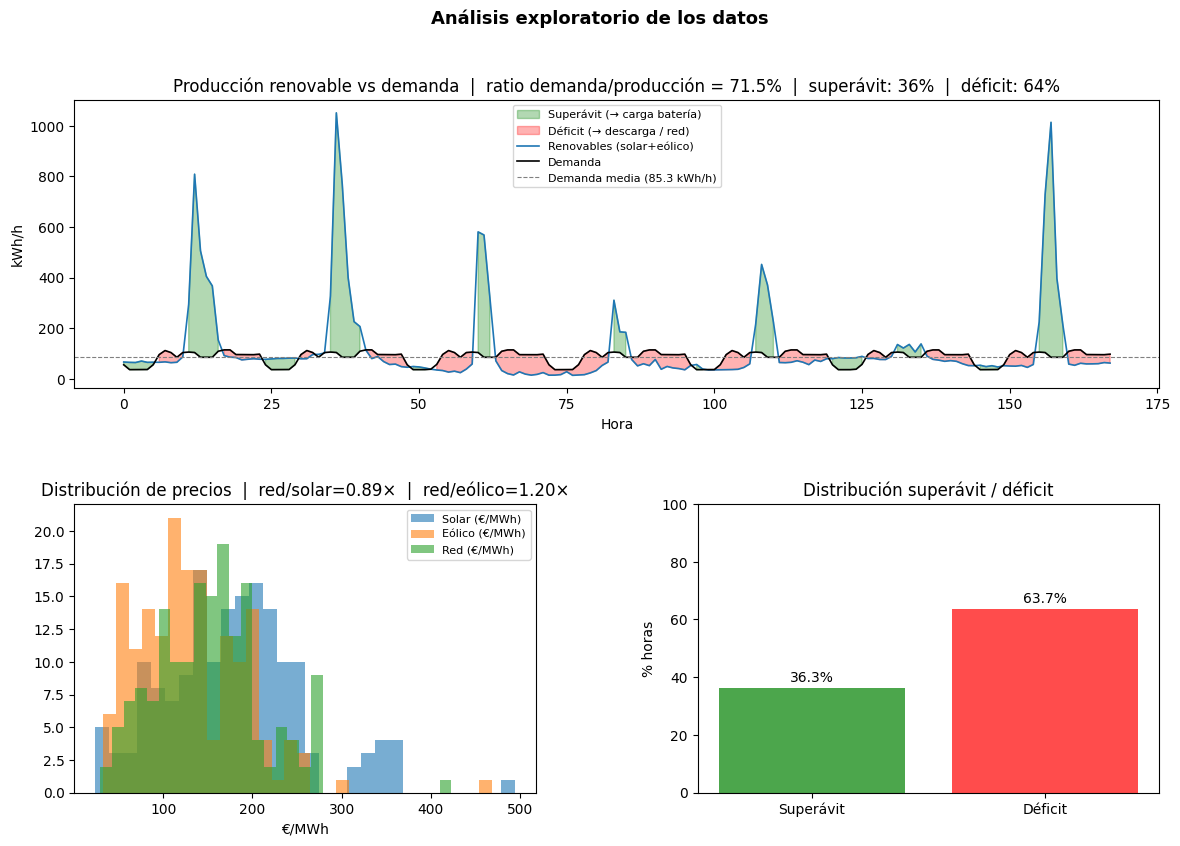

In [5]:
prod_media   = (P_SOLAR + P_WIND).mean()
dem_media    = DEMAND.mean()
ratio_dem    = dem_media / prod_media

horas_superavit = ((P_SOLAR + P_WIND) >= DEMAND).mean() * 100
horas_deficit   = 100 - horas_superavit

ratio_grid_solar = (A_GRID / np.where(A_SOLAR > 0, A_SOLAR, np.nan)).mean()
ratio_grid_wind  = (A_GRID / np.where(A_WIND  > 0, A_WIND,  np.nan)).mean()

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Producción renovable vs demanda hora a hora
ax0 = fig.add_subplot(gs[0, :])
horas = np.arange(T)
ax0.fill_between(horas, P_SOLAR + P_WIND, DEMAND,
                 where=(P_SOLAR+P_WIND) >= DEMAND,
                 alpha=0.3, color='green', label='Superávit (→ carga batería)')
ax0.fill_between(horas, P_SOLAR + P_WIND, DEMAND,
                 where=(P_SOLAR+P_WIND) <  DEMAND,
                 alpha=0.3, color='red',   label='Déficit (→ descarga / red)')
ax0.plot(horas, P_SOLAR + P_WIND, label='Renovables (solar+eólico)', lw=1.2)
ax0.plot(horas, DEMAND,           label='Demanda',  lw=1.2, color='k')
ax0.axhline(dem_media, ls='--', color='gray', lw=0.8, label=f'Demanda media ({dem_media:.1f} kWh/h)')
ax0.set_title(
    f'Producción renovable vs demanda  |  ratio demanda/producción = {ratio_dem:.1%}'
    f'  |  superávit: {horas_superavit:.0f}%  |  déficit: {horas_deficit:.0f}%'
)
ax0.set_xlabel('Hora')
ax0.set_ylabel('kWh/h')
ax0.legend(fontsize=8)

# Distribución de precios
ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(A_SOLAR * 1000, bins=30, alpha=0.6, label='Solar (€/MWh)')
ax1.hist(A_WIND  * 1000, bins=30, alpha=0.6, label='Eólico (€/MWh)')
ax1.hist(A_GRID  * 1000, bins=30, alpha=0.6, label='Red (€/MWh)')
ax1.set_title(f'Distribución de precios  |  red/solar={ratio_grid_solar:.2f}×  |  red/eólico={ratio_grid_wind:.2f}×')
ax1.set_xlabel('€/MWh')
ax1.legend(fontsize=8)

# Proporción superávit / déficit
ax2 = fig.add_subplot(gs[1, 1])
ax2.bar(['Superávit', 'Déficit'], [horas_superavit, horas_deficit], color=['green', 'red'], alpha=0.7)
ax2.set_ylabel('% horas')
ax2.set_title('Distribución superávit / déficit')
ax2.set_ylim(0, 100)
for bar, val in zip(ax2.patches, [horas_superavit, horas_deficit]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Análisis exploratorio de los datos', fontsize=13, fontweight='bold')
plt.show()

## 3. Definición del problema

### Individuo:

 $[x1_0,\ldots,x1_{T-1} \mid x2_0,\ldots,x2_{T-1} \mid b_0,\ldots,b_{T-1}]$, donde:
 * $x1_t$ : Energía comprada al generador solar en la hora $t$
 * $x2_t$ : Energía comprada al generador eólico en la hora $t$ 
 * $b_t$  : Energía neta que coje la batería desde las renovables

En el documento se explican las restricciones impuestas a cada variable.


### Estado de Carga (SOC)
Definimos SOC que se usa internamente en el método de reparación. Esta restricción, no es ni sobre las variables ni sobre los objetivos. Aunque indirectamente sí es una restricción sobre las variables. Se impone la siguiente restricción que sirve para b_t actúe en concordancia con el estado de carga:

$	{SOC}_{\min} \leq 	{soc}_t \leq 	{SOC}_{\max}$ 


### Funciones Objetivo 
Minimizamos los siguientes objetivos:

$$ f_1 = \sum_{t=0}^{T-1} \bigl[a_{1,t}\,x_{1,t} + a_{2,t}\,x_{2,t} + a_{3,t}\,g_t\bigr] $$

$$f_2 = \sum_{t} 	{g}_t \qquad $$


In [6]:
class Microgrid(FloatProblem):
    """Despacho bi-objetivo de una microred con batería (coste vs energía de red)."""

    def __init__(self, demand, p_solar, p_wind, a_solar, a_wind, a_grid,
                 bat_capacity, bat_soc_ini, bat_soc_min, bat_soc_max,
                 bat_eff_c, bat_eff_d):
        super().__init__()
        self.d    = np.asarray(demand,  dtype=float)
        self.ps   = np.asarray(p_solar, dtype=float)
        self.pw   = np.asarray(p_wind,  dtype=float)
        self.a1   = np.asarray(a_solar, dtype=float)
        self.a2   = np.asarray(a_wind,  dtype=float)
        self.a3   = np.asarray(a_grid,  dtype=float)
        self.T    = len(self.d)
        self.bat_cap     = bat_capacity
        self.bat_soc_ini = bat_soc_ini
        self.bat_soc_min = bat_soc_min
        self.bat_soc_max = bat_soc_max
        self.eff_c       = bat_eff_c
        self.eff_d       = bat_eff_d

        # b: bidireccional en [-bat_cap, +bat_cap]
        self.lower_bound = [0.0] * self.T + [0.0] * self.T + [-self.bat_cap] * self.T
        self.upper_bound = list(self.ps) + list(self.pw) + [self.bat_cap] * self.T
        self.obj_directions = [self.MINIMIZE, self.MINIMIZE]
        self.obj_labels     = ['Coste (€)', 'Energia red (kWh)']

    def number_of_variables(self)   -> int: return 3 * self.T
    def number_of_objectives(self)  -> int: return 2
    def number_of_constraints(self) -> int: return 0
    def name(self)                  -> str: return 'Microgrid Coordination'

    def _repair(self, variables):
        x  = np.asarray(variables, dtype=float)
        x1 = np.clip(x[:self.T],         0.0, self.ps)
        x2 = np.clip(x[self.T:2*self.T], 0.0, self.pw)
        b  = np.clip(x[2*self.T:],       -self.bat_cap, self.bat_cap)

        soc   = self.bat_soc_ini
        b_rep = np.empty(self.T)
        for t in range(self.T):
            bt = b[t]
            if bt >= 0:  # intento de carga
                max_charge = (self.bat_soc_max - soc) / self.eff_c
                bt = min(bt, max_charge)
                # solo se puede cargar con superávit renovable (no desde la red)
                surplus = max(0.0, x1[t] + x2[t] - self.d[t])
                bt = min(bt, surplus)
                soc += bt * self.eff_c
            else:  # intento de descarga
                max_discharge = (soc - self.bat_soc_min) * self.eff_d
                bt = max(bt, -max_discharge)
                soc += bt / self.eff_d
            b_rep[t] = bt
        return x1, x2, b_rep

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        x1, x2, b = self._repair(solution.variables)
        solution.variables = np.concatenate([x1, x2, b]).tolist()

        deficit = np.maximum(0.0, self.d - x1 - x2 + b)

        f1 = float(self.a1 @ x1 + self.a2 @ x2 + self.a3 @ deficit)
        f2 = float(deficit.sum())

        solution.objectives[0] = f1
        solution.objectives[1] = f2
        return solution


# Instanciar el problema sobre la ventana cargada (con batería)
problem = Microgrid(
    DEMAND, P_SOLAR, P_WIND, A_SOLAR, A_WIND, A_GRID,
    bat_capacity = BATTERY_CAPACITY,
    bat_soc_ini  = BATTERY_SOC_INI_KWH,
    bat_soc_min  = BATTERY_SOC_MIN_KWH,
    bat_soc_max  = BATTERY_SOC_MAX_KWH,
    bat_eff_c    = BATTERY_EFF_C,
    bat_eff_d    = BATTERY_EFF_D,
)
print(f'Problema listo: {problem.name()}')
print(f'Variables: {problem.number_of_variables()}  |  Objetivos: {problem.number_of_objectives()}')
print(f'  x1 (solar)  : {problem.T} variables  [0, P_solar_t]')
print(f'  x2 (eólico) : {problem.T} variables  [0, P_wind_t]')
print(f'  b  (batería): {problem.T} variables  [-{BATTERY_CAPACITY:.1f}, +{BATTERY_CAPACITY:.1f}] kWh')

Problema listo: Microgrid Coordination
Variables: 504  |  Objetivos: 2
  x1 (solar)  : 168 variables  [0, P_solar_t]
  x2 (eólico) : 168 variables  [0, P_wind_t]
  b  (batería): 168 variables  [-256.0, +256.0] kWh


## 4. Cotas del espacio objetivo y punto de referencia del HV

In [7]:
# Se calculan lo extremos de cada objetivo. Para simplificar el problema, hemos calculado olvidándonos de la batería.
# f1_min --> fuentes más baratas en cada momento
# f1_max --> fuentes más caras
# f2_min --> coger todo lo posible de las renovables
# f2_max --> coger todo de la red

def objective_bounds(d, ps, pw, a_s, a_w, a_g):
    f1_min = f1_max = 0.0
    for t in range(len(d)):
        srcs = [(a_s[t], ps[t]), (a_w[t], pw[t])]
        rem, c = d[t], 0.0                                   # coste mínimo
        for price, cap in sorted(srcs, key=lambda z: z[0]):
            if price < a_g[t]:
                u = min(cap, rem); c += price * u; rem -= u
        c += a_g[t] * rem; f1_min += c
        rem, c = d[t], 0.0                                   # coste máximo
        for price, cap in sorted(srcs, key=lambda z: -z[0]):
            if price > a_g[t]:
                u = min(cap, rem); c += price * u; rem -= u
        c += a_g[t] * rem; f1_max += c
    f2_min = float(np.maximum(0.0, d - ps - pw).sum())
    f2_max = float(d.sum())
    return f1_min, f1_max, f2_min, f2_max

MARGIN = 0.1
F1_MIN, F1_MAX, F2_MIN, F2_MAX = objective_bounds(DEMAND, P_SOLAR, P_WIND, A_SOLAR, A_WIND, A_GRID)
area_espacio    = (F1_MAX - F1_MIN) * (F2_MAX - F2_MIN)
REFERENCE_POINT = np.array([F1_MAX, F2_MAX]) * (1 + MARGIN)

print(f'f1 (coste)       : min {F1_MIN:.4f} €   | max {F1_MAX:.4f} €')
print(f'f2 (energia red) : min {F2_MIN:.2f} kWh | max {F2_MAX:.2f} kWh')
print(f'Área espacio objetivo: {area_espacio:.4f}')
print(f'Punto de referencia HV: coste={REFERENCE_POINT[0]:.4f} €, energia_red={REFERENCE_POINT[1]:.2f} kWh')

f1 (coste)       : min 2021.2557 €   | max 2304.3615 €
f2 (energia red) : min 4111.44 kWh | max 14336.17 kWh
Área espacio objetivo: 2894682.6785
Punto de referencia HV: coste=2534.7977 €, energia_red=15769.79 kWh


## 5. Función auxiliar: ejecutar un algoritmo y calcular su HV

In [ ]:
def run_algorithm(algo_name: str, population_size: int, eta_c: float, eta_m: float,
                  crossover_prob: float, seed: int,
                  generations: int = None) -> dict:
    """Ejecuta NSGA-II o SPEA2 con los hiperparámetros dados y devuelve HV, nº de soluciones y tiempo.
    generations: número de generaciones. Si no se pasa, usa GENERATIONS_FINAL.
    """
    if generations is None:
        generations = GENERATIONS_FINAL

    random.seed(seed)
    np.random.seed(seed)

    mutation_prob   = 1.0 / problem.number_of_variables()
    max_evaluations = population_size * generations

    crossover_op = SBXCrossover(probability=crossover_prob, distribution_index=eta_c)
    mutation_op  = PolynomialMutation(probability=mutation_prob, distribution_index=eta_m)
    termination  = StoppingByEvaluations(max_evaluations=max_evaluations)

    t0 = time.time()
    if algo_name == 'NSGAII':
        algo = NSGAII(problem=problem, population_size=population_size,
                      offspring_population_size=population_size,
                      mutation=mutation_op, crossover=crossover_op,
                      termination_criterion=termination)
    elif algo_name == 'SPEA2':
        algo = SPEA2(problem=problem, population_size=population_size,
                     offspring_population_size=population_size,
                     mutation=mutation_op, crossover=crossover_op,
                     termination_criterion=termination)
    else:
        raise ValueError(f'Algoritmo desconocido: {algo_name}')

    algo.run()
    elapsed = time.time() - t0

    front     = get_non_dominated_solutions(algo.result())
    front_arr = np.array([s.objectives for s in front])
    hv_ind    = HyperVolume(REFERENCE_POINT.tolist())
    hv        = hv_ind.compute(front_arr.tolist()) if len(front) > 0 else 0.0

    return {'hv': hv, 'n_solutions': len(front), 'elapsed_s': elapsed}

print('Función run_algorithm definida.')

Función run_algorithm definida.


## 6. Búsqueda con Optuna

In [9]:
# Hemos lanzado dos estudios: uno por algoritmo
# Objetivo de Optuna: MAXIMIZAR la MEDIANA del HV sobre N_RUNS_SEARCH semillas.

optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(algo_name):
    def objective(trial):
        eta_c = trial.suggest_float('eta_c',          *SEARCH_SPACE['eta_c'])
        eta_m = trial.suggest_float('eta_m',          *SEARCH_SPACE['eta_m'])
        cx    = trial.suggest_float('crossover_prob', *SEARCH_SPACE['crossover_prob'])

        hv_runs, elapsed_runs = [], []
        for r in range(N_RUNS_SEARCH):
            seed = BASE_SEED + r * 1000
            try:
                out = run_algorithm(algo_name, POPULATION_SIZE, eta_c, eta_m, cx, seed,
                                    generations=GENERATIONS_SEARCH)
                hv_runs.append(out['hv'])
                elapsed_runs.append(out['elapsed_s'])
            except Exception as e:
                print(f'  Error en {algo_name} run {r}: {e}')
                hv_runs.append(np.nan); elapsed_runs.append(np.nan)

        trial.set_user_attr('hv_mean',        float(np.nanmean(hv_runs)))
        trial.set_user_attr('hv_std',         float(np.nanstd(hv_runs)))
        trial.set_user_attr('hv_min',         float(np.nanmin(hv_runs)))
        trial.set_user_attr('hv_max',         float(np.nanmax(hv_runs)))
        trial.set_user_attr('elapsed_mean_s', float(np.nanmean(elapsed_runs)))
        trial.set_user_attr('hv_runs',        [float(h) for h in hv_runs])
        return float(np.nanmedian(hv_runs))   # se MAXIMIZA
    return objective

results   = []
studies   = {}
best_params = {}

DB_PATH = 'sqlite:///optuna_microred.db'

for algo_name in ALGORITHMS:
    print(f"\n{'='*60}\n Optuna -> {algo_name}  "
          f"({N_TRIALS} trials × {N_RUNS_SEARCH} runs × {GENERATIONS_SEARCH} gen)\n{'='*60}")
    sampler = optuna.samplers.TPESampler(seed=BASE_SEED)
    study   = optuna.create_study(direction='maximize', sampler=sampler,
                                  study_name=algo_name, storage=DB_PATH,
                                  load_if_exists=True)
    study.optimize(make_objective(algo_name), n_trials=N_TRIALS, show_progress_bar=True)

    studies[algo_name]     = study
    best_params[algo_name] = study.best_params
    print(f'  Mejor HV (mediana) {algo_name}: {study.best_value:.6f}')
    print(f'  Mejores parámetros : {study.best_params}')

    for t in study.trials:
        results.append({
            'algorithm'      : algo_name,
            'population_size': POPULATION_SIZE,
            'eta_c'          : t.params.get('eta_c'),
            'eta_m'          : t.params.get('eta_m'),
            'crossover_prob' : t.params.get('crossover_prob'),
            'hv_median'      : t.value,
            'hv_mean'        : t.user_attrs.get('hv_mean'),
            'hv_std'         : t.user_attrs.get('hv_std'),
            'hv_min'         : t.user_attrs.get('hv_min'),
            'hv_max'         : t.user_attrs.get('hv_max'),
            'elapsed_mean_s' : t.user_attrs.get('elapsed_mean_s'),
            'hv_runs'        : t.user_attrs.get('hv_runs'),
        })

print('\nBúsqueda Optuna completada.')
print(f'Base de datos Optuna guardada en: {DB_PATH}')


 Optuna -> NSGAII  (20 trials × 3 runs × 150 gen)


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2026-06-11 16:15:45,352] Trial 20 failed with parameters: {'eta_c': 25.928604213140762, 'eta_m': 20.53728777030809, 'crossover_prob': 0.8492076922317024} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\alaiu\Desktop\MASTER\4.Hiruhilekoa\Reto04_Grupo05\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\alaiu\AppData\Local\Temp\ipykernel_30312\320139440.py", line 16, in objective
    out = run_algorithm(algo_name, POPULATION_SIZE, eta_c, eta_m, cx, seed,
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alaiu\AppData\Local\Temp\ipykernel_30312\1846195929.py", line 35, in run_algorithm
    algo.run()
  File "c:\Users\alaiu\Desktop\MASTER\4.Hiruhilekoa\Reto04_Grupo05\.venv\Lib\site-packages\jmetal\core\algorithm.py", line 86, in run
    self.step()
  File "c:\Users\alaiu\Desktop\M

KeyboardInterrupt: 

## 6.a Ejecución — NSGA-II

Ejecución con el presupuesto completo (`GENERATIONS_FINAL`) usando los mejores hiperparámetros encontrados por Optuna. Se analiza el frente de Pareto resultante y el comportamiento de la batería en tres soluciones representativas: mínimo coste, punto medio y mínimo déficit.

best_params cargados desde sqlite:///optuna_microred.db
NSGAII | η_c=29.86, η_m=21.61, p_cruce=0.933
Soluciones no dominadas: 41  |  HV: 6547008.912539  |  Tiempo: 247.6 s
Coste: [1980.77, 1988.08] €
Red:   [3952.28, 4007.57] kWh


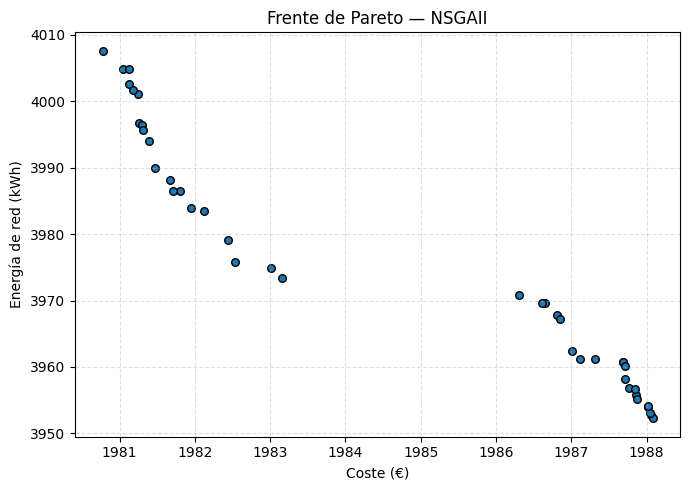

In [10]:
# Cargar best_params desde la BD de Optuna si no están ya en memoria
if 'best_params' not in dir() or not best_params:
    _DB_PATH = 'sqlite:///optuna_microred.db'
    best_params = {}
    for _algo in ['NSGAII', 'SPEA2']:
        _study = optuna.load_study(study_name=_algo, storage=_DB_PATH)
        best_params[_algo] = _study.best_params
    print(f'best_params cargados desde {_DB_PATH}')

algo_name      = 'NSGAII'
eta_c          = best_params['NSGAII']['eta_c']
eta_m          = best_params['NSGAII']['eta_m']
crossover_prob = best_params['NSGAII']['crossover_prob']
seed           = BASE_SEED

random.seed(seed)
np.random.seed(seed)
mutation_prob   = 1.0 / problem.number_of_variables()
max_evaluations = POPULATION_SIZE * GENERATIONS_FINAL

algo = NSGAII(
    problem=problem,
    population_size=POPULATION_SIZE,
    offspring_population_size=POPULATION_SIZE,
    mutation=PolynomialMutation(probability=mutation_prob, distribution_index=eta_m),
    crossover=SBXCrossover(probability=crossover_prob, distribution_index=eta_c),
    termination_criterion=StoppingByEvaluations(max_evaluations=max_evaluations),
)

t0 = time.time()
algo.run()
elapsed = time.time() - t0

front       = get_non_dominated_solutions(algo.result())
front_arr   = np.array([s.objectives for s in front])
n_solutions = len(front_arr)
hv          = HyperVolume(REFERENCE_POINT.tolist()).compute(front_arr.tolist()) if n_solutions > 0 else 0.0

print(f'{algo_name} | η_c={eta_c:.2f}, η_m={eta_m:.2f}, p_cruce={crossover_prob:.3f}')
print(f'Soluciones no dominadas: {n_solutions}  |  HV: {hv:.6f}  |  Tiempo: {elapsed:.1f} s')
print(f'Coste: [{front_arr[:,0].min():.2f}, {front_arr[:,0].max():.2f}] €')
print(f'Red:   [{front_arr[:,1].min():.2f}, {front_arr[:,1].max():.2f}] kWh')

plt.figure(figsize=(7, 5))
plt.scatter(front_arr[:, 0], front_arr[:, 1], c='C0', edgecolors='k', s=30)
plt.title(f'Frente de Pareto — {algo_name}')
plt.xlabel('Coste (€)')
plt.ylabel('Energía de red (kWh)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

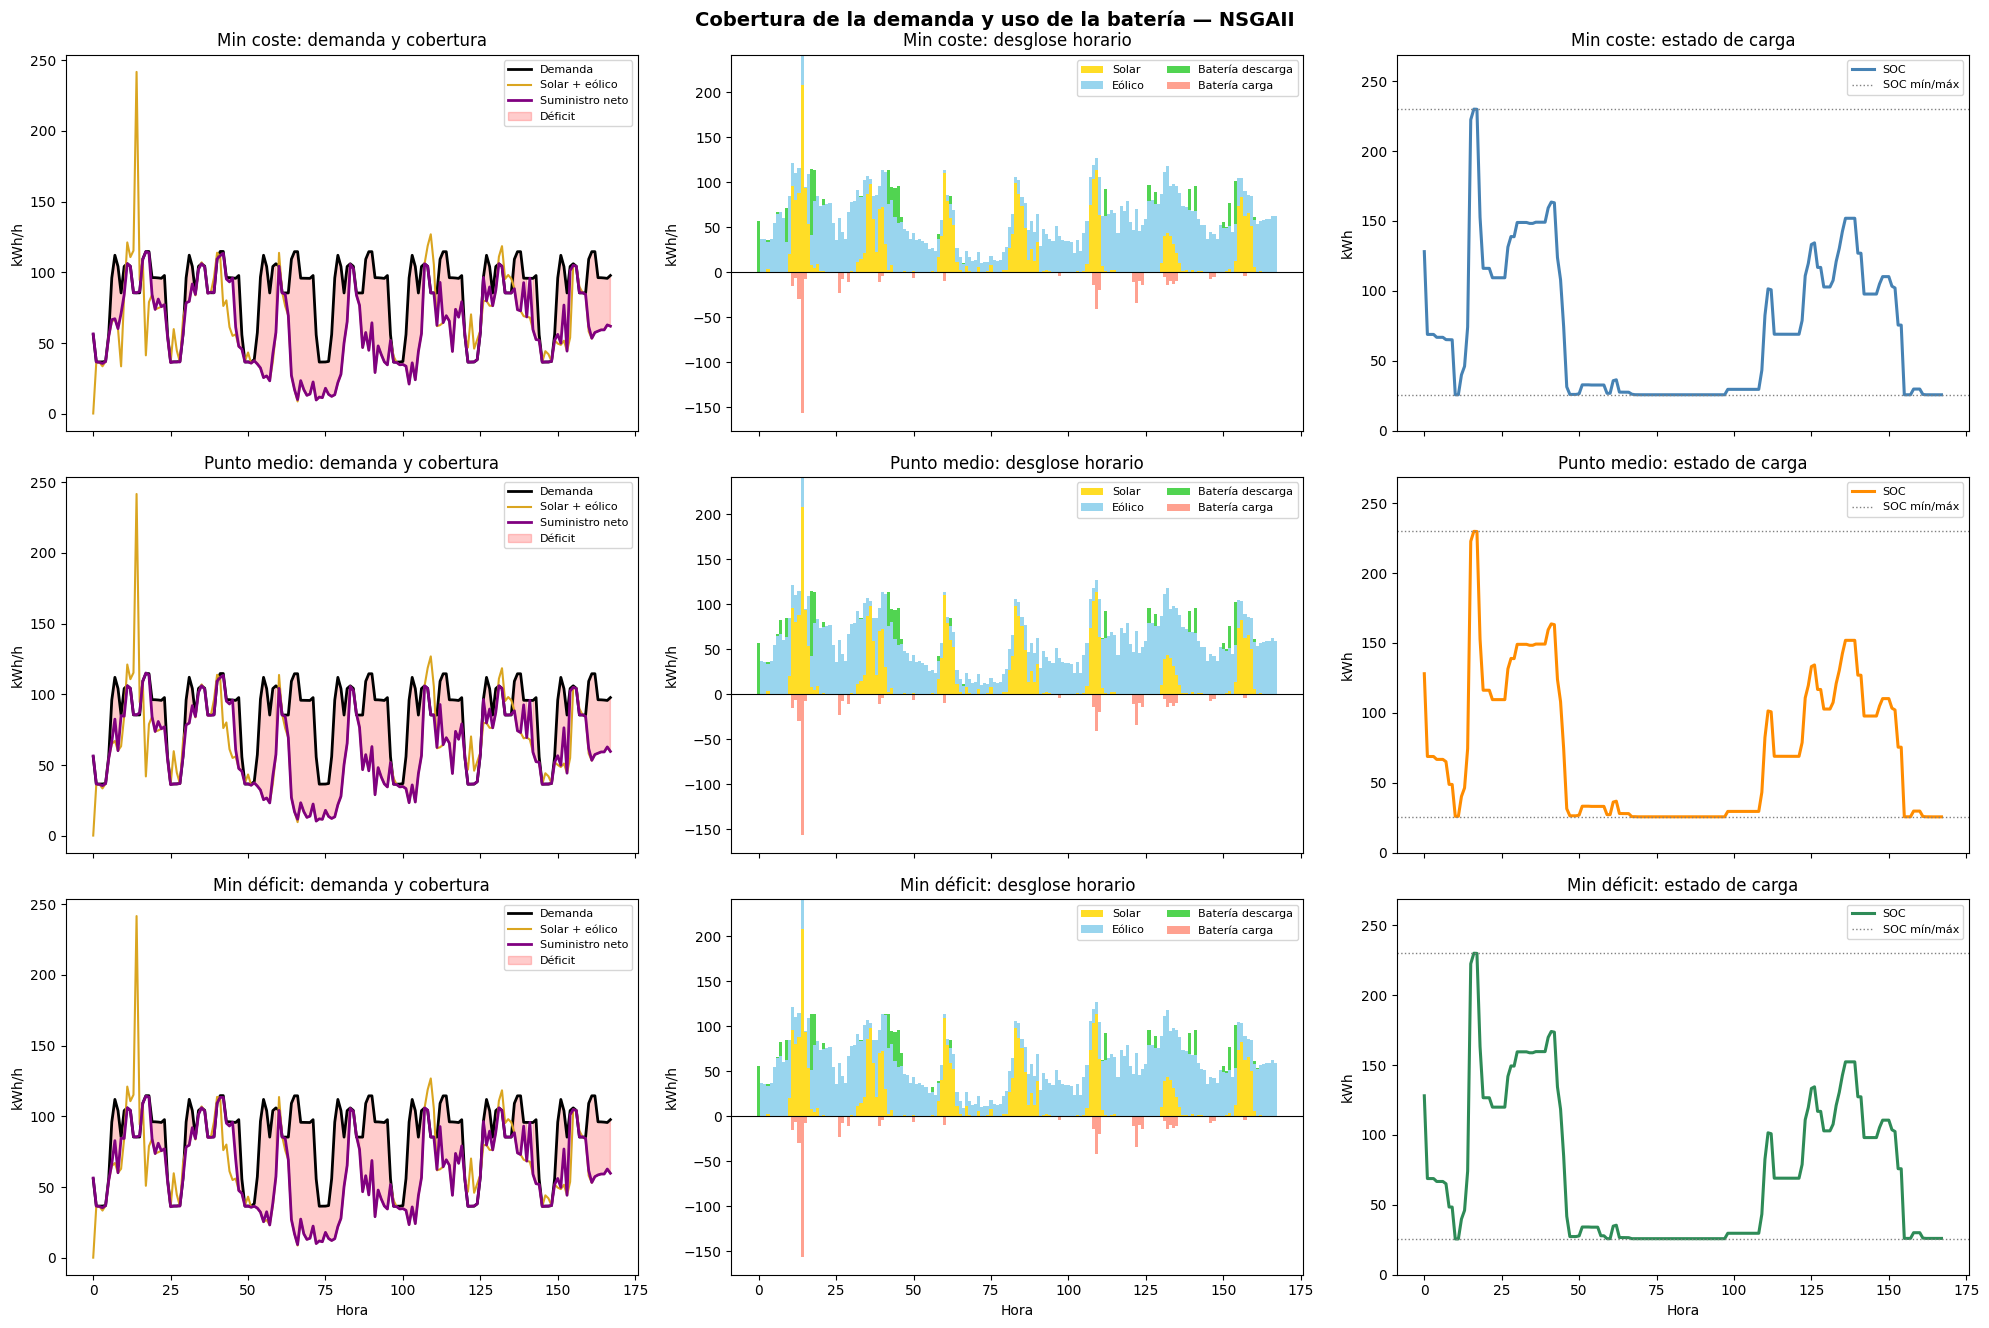

In [11]:
if n_solutions > 0:
    idx_sorted     = np.argsort(front_arr[:, 0])
    idx_low_cost   = idx_sorted[0]
    idx_low_deficit= idx_sorted[-1]
    idx_mid        = idx_sorted[len(idx_sorted)//2]

    labels = ['Min coste', 'Punto medio', 'Min déficit']
    idxs   = [idx_low_cost, idx_mid, idx_low_deficit]
    colors = ['steelblue', 'darkorange', 'seagreen']
    horas  = np.arange(T)

    fig, axes = plt.subplots(len(idxs), 3, figsize=(20, 4.5 * len(idxs)), sharex=True)

    for row, (idx, label, color) in enumerate(zip(idxs, labels, colors)):
        sol   = front[idx]
        vars_ = np.array(sol.variables)
        x1 = vars_[:T]
        x2 = vars_[T:2*T]
        b  = vars_[2*T:]

        # Reconstruir SOC hora a hora (soc[t] = estado al inicio de la hora t)
        soc = np.empty(T)
        soc_curr = BATTERY_SOC_INI_KWH
        for t in range(T):
            soc[t] = soc_curr
            soc_curr += b[t] * BATTERY_EFF_C if b[t] >= 0 else b[t] / BATTERY_EFF_D

        battery_discharge = np.maximum(0, -b)   # aporta a la demanda
        battery_charge    = np.maximum(0,  b)   # consume de renovables
        # supply_t = x1 + x2 - b  (b>0 carga: reduce supply; b<0 descarga: aumenta supply)
        supply = x1 + x2 - b
        deficit = np.maximum(0, DEMAND - supply)

        # Panel 1: demanda vs cobertura neta
        ax = axes[row, 0]
        ax.plot(horas, DEMAND,  color='black',     lw=2.0, label='Demanda')
        ax.plot(horas, x1 + x2, color='goldenrod', lw=1.5, label='Solar + eólico')
        ax.plot(horas, supply,  color='purple',    lw=2.0, label='Suministro neto')
        ax.fill_between(horas, supply, DEMAND, where=supply < DEMAND,
                        color='red', alpha=0.2, label='Déficit')
        ax.set_title(f'{label}: demanda y cobertura')
        ax.set_ylabel('kWh/h')
        ax.legend(fontsize=8)

        # Panel 2: desglose horario del suministro
        ax = axes[row, 1]
        ax.bar(horas, x1,                                  color='gold',      alpha=0.85, label='Solar',            width=1.0)
        ax.bar(horas, x2,              bottom=x1,          color='skyblue',   alpha=0.85, label='Eólico',           width=1.0)
        ax.bar(horas, battery_discharge, bottom=x1+x2,     color='limegreen', alpha=0.85, label='Batería descarga', width=1.0)
        ax.bar(horas, -battery_charge,                     color='tomato',    alpha=0.6,  label='Batería carga',    width=1.0)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_title(f'{label}: desglose horario')
        ax.set_ylabel('kWh/h')
        ax.legend(fontsize=8, ncol=2)

        # Panel 3: estado de carga (SOC)
        ax = axes[row, 2]
        ax.plot(horas, soc, color=color, lw=2.2, label='SOC')
        ax.axhline(BATTERY_SOC_MIN_KWH, color='gray', ls=':', lw=1.0, label='SOC mín/máx')
        ax.axhline(BATTERY_SOC_MAX_KWH, color='gray', ls=':', lw=1.0)
        ax.set_ylim(0, BATTERY_CAPACITY * 1.05)
        ax.set_title(f'{label}: estado de carga')
        ax.set_ylabel('kWh')
        ax.legend(fontsize=8)

    for ax in axes[-1, :]:
        ax.set_xlabel('Hora')

    plt.suptitle(f'Cobertura de la demanda y uso de la batería — {algo_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Vemos que las tres casuísticas son casi exactas. Hemos visto en el frente de pareto que la diferencia en precio desde el más barato al más caro es muy pequeña (7€). Es por ello que la política de uso de batería que emplean los tres individuos es muy similar. Se ve cuando hay un pico extremo de energia de fuentes renovables (primer día por ejemplo) la batería se carga al tope.

En la manera en que hemos diseñado el precio de cada fuente, esto tiene sentido, porque el excedente va acorde al precio.

Apreciamos que en las horas del mediodía, cuando el precio del solar es más bajo, consumimos de esa fuente o cargamos en esos casos sólo la batería.

## 6.b Ejecución — SPEA2

SPEA2 | η_c=22.70, η_m=5.51, p_cruce=0.991
Soluciones no dominadas: 55  |  HV: 6720508.080358  |  Tiempo: 291.3 s
Coste: [1966.74, 1979.83] €
Red:   [3937.25, 4251.74] kWh


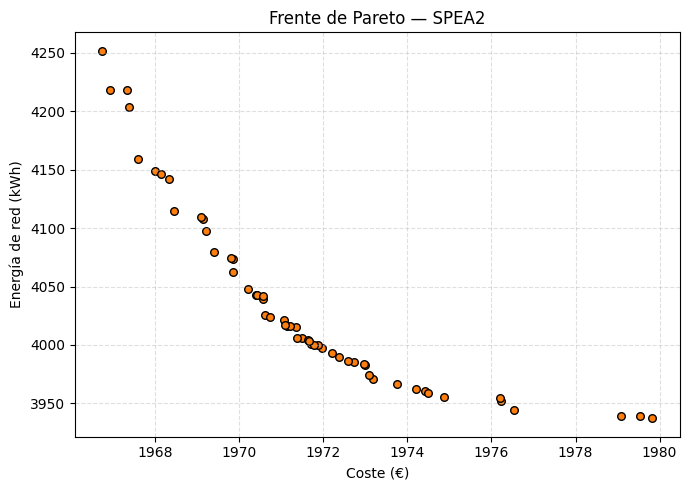

In [12]:
# Cargar best_params desde la BD de Optuna si no están ya en memoria
if 'best_params' not in dir() or not best_params:
    _DB_PATH = 'sqlite:///optuna_microred.db'
    best_params = {}
    for _algo in ['NSGAII', 'SPEA2']:
        _study = optuna.load_study(study_name=_algo, storage=_DB_PATH)
        best_params[_algo] = _study.best_params
    print(f'best_params cargados desde {_DB_PATH}')

algo_name      = 'SPEA2'
eta_c          = best_params['SPEA2']['eta_c']
eta_m          = best_params['SPEA2']['eta_m']
crossover_prob = best_params['SPEA2']['crossover_prob']
seed           = BASE_SEED

random.seed(seed)
np.random.seed(seed)
mutation_prob   = 1.0 / problem.number_of_variables()
max_evaluations = POPULATION_SIZE * GENERATIONS_FINAL

algo = SPEA2(
    problem=problem,
    population_size=POPULATION_SIZE,
    offspring_population_size=POPULATION_SIZE,
    mutation=PolynomialMutation(probability=mutation_prob, distribution_index=eta_m),
    crossover=SBXCrossover(probability=crossover_prob, distribution_index=eta_c),
    termination_criterion=StoppingByEvaluations(max_evaluations=max_evaluations),
)

t0 = time.time()
algo.run()
elapsed = time.time() - t0

front_spea2     = get_non_dominated_solutions(algo.result())
front_arr_spea2 = np.array([s.objectives for s in front_spea2])
n_solutions_spea2 = len(front_arr_spea2)
hv_spea2 = HyperVolume(REFERENCE_POINT.tolist()).compute(front_arr_spea2.tolist()) if n_solutions_spea2 > 0 else 0.0

print(f'{algo_name} | η_c={eta_c:.2f}, η_m={eta_m:.2f}, p_cruce={crossover_prob:.3f}')
print(f'Soluciones no dominadas: {n_solutions_spea2}  |  HV: {hv_spea2:.6f}  |  Tiempo: {elapsed:.1f} s')
print(f'Coste: [{front_arr_spea2[:,0].min():.2f}, {front_arr_spea2[:,0].max():.2f}] €')
print(f'Red:   [{front_arr_spea2[:,1].min():.2f}, {front_arr_spea2[:,1].max():.2f}] kWh')

plt.figure(figsize=(7, 5))
plt.scatter(front_arr_spea2[:, 0], front_arr_spea2[:, 1], c='C1', edgecolors='k', s=30)
plt.title(f'Frente de Pareto — {algo_name}')
plt.xlabel('Coste (€)')
plt.ylabel('Energía de red (kWh)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Este frente parece mejor en cuanto a diversidad. El eje X abarca mayor ventana. NSGA-II contiene 41 individuos en el frente de Pareto mientras que SPEA2 tiene 55.

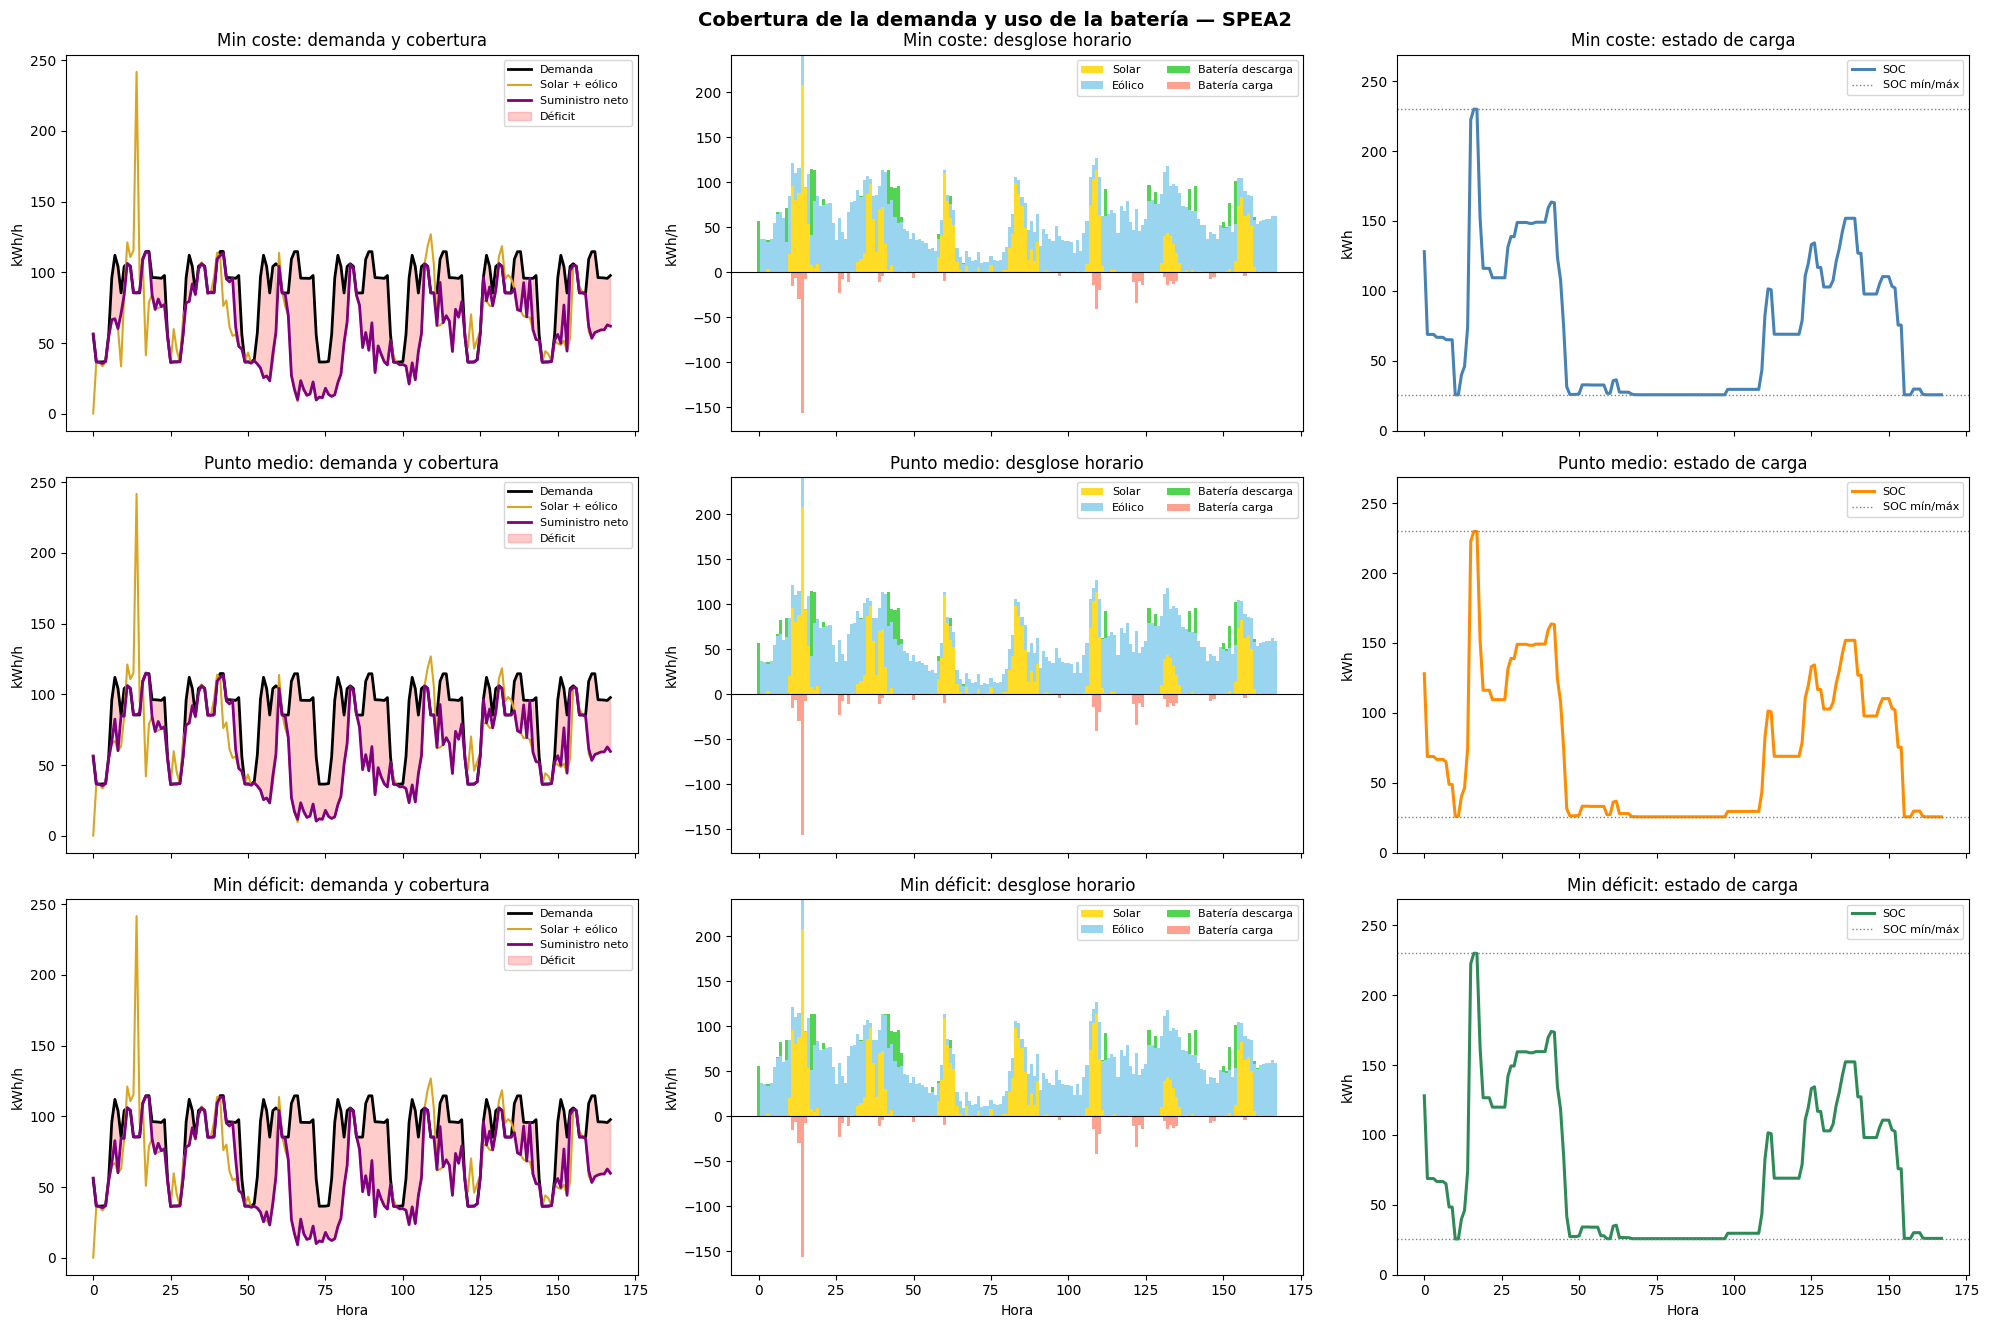

In [13]:
idx_sorted     = np.argsort(front_arr[:, 0])
idx_low_cost   = idx_sorted[0]
idx_low_deficit= idx_sorted[-1]
idx_mid        = idx_sorted[len(idx_sorted)//2]

labels = ['Min coste', 'Punto medio', 'Min déficit']
idxs   = [idx_low_cost, idx_mid, idx_low_deficit]
colors = ['steelblue', 'darkorange', 'seagreen']
horas  = np.arange(T)

fig, axes = plt.subplots(len(idxs), 3, figsize=(20, 4.5 * len(idxs)), sharex=True)

for row, (idx, label, color) in enumerate(zip(idxs, labels, colors)):
    sol   = front[idx]
    vars_ = np.array(sol.variables)
    x1 = vars_[:T]
    x2 = vars_[T:2*T]
    b  = vars_[2*T:]

    # Reconstruir SOC hora a hora (soc[t] = estado al inicio de la hora t)
    soc = np.empty(T)
    soc_curr = BATTERY_SOC_INI_KWH
    for t in range(T):
        soc[t] = soc_curr
        soc_curr += b[t] * BATTERY_EFF_C if b[t] >= 0 else b[t] / BATTERY_EFF_D

    battery_discharge = np.maximum(0, -b)   # aporta a la demanda
    battery_charge    = np.maximum(0,  b)   # consume de renovables
    # supply_t = x1 + x2 - b  (b>0 carga: reduce supply; b<0 descarga: aumenta supply)
    supply = x1 + x2 - b
    deficit = np.maximum(0, DEMAND - supply)

    # Panel 1: demanda vs cobertura neta
    ax = axes[row, 0]
    ax.plot(horas, DEMAND,  color='black',     lw=2.0, label='Demanda')
    ax.plot(horas, x1 + x2, color='goldenrod', lw=1.5, label='Solar + eólico')
    ax.plot(horas, supply,  color='purple',    lw=2.0, label='Suministro neto')
    ax.fill_between(horas, supply, DEMAND, where=supply < DEMAND,
                        color='red', alpha=0.2, label='Déficit')
    ax.set_title(f'{label}: demanda y cobertura')
    ax.set_ylabel('kWh/h')
    ax.legend(fontsize=8)

    # Panel 2: desglose horario del suministro
    ax = axes[row, 1]
    ax.bar(horas, x1,                                  color='gold',      alpha=0.85, label='Solar',            width=1.0)
    ax.bar(horas, x2,              bottom=x1,          color='skyblue',   alpha=0.85, label='Eólico',           width=1.0)
    ax.bar(horas, battery_discharge, bottom=x1+x2,     color='limegreen', alpha=0.85, label='Batería descarga', width=1.0)
    ax.bar(horas, -battery_charge,                     color='tomato',    alpha=0.6,  label='Batería carga',    width=1.0)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{label}: desglose horario')
    ax.set_ylabel('kWh/h')
    ax.legend(fontsize=8, ncol=2)

    # Panel 3: estado de carga (SOC)
    ax = axes[row, 2]
    ax.plot(horas, soc, color=color, lw=2.2, label='SOC')
    ax.axhline(BATTERY_SOC_MIN_KWH, color='gray', ls=':', lw=1.0, label='SOC mín/máx')
    ax.axhline(BATTERY_SOC_MAX_KWH, color='gray', ls=':', lw=1.0)
    ax.set_ylim(0, BATTERY_CAPACITY * 1.05)
    ax.set_title(f'{label}: estado de carga')
    ax.set_ylabel('kWh')
    ax.legend(fontsize=8)

for ax in axes[-1, :]:
    ax.set_xlabel('Hora')

plt.suptitle(f'Cobertura de la demanda y uso de la batería — {algo_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El comportamiento es  muy similar a NSGA-II y tiene sentido.

## 7. Guardar resultados

In [14]:
# Reconstruir results desde la BD si no está en memoria (p.ej. si se saltó la celda de Optuna)
if 'results' not in dir() or not results:
    _DB_PATH = 'sqlite:///optuna_microred.db'
    results = []
    for _algo in ALGORITHMS:
        _study = optuna.load_study(study_name=_algo, storage=_DB_PATH)
        for t in _study.trials:
            results.append({
                'algorithm'      : _algo,
                'population_size': POPULATION_SIZE,
                'eta_c'          : t.params.get('eta_c'),
                'eta_m'          : t.params.get('eta_m'),
                'crossover_prob' : t.params.get('crossover_prob'),
                'hv_median'      : t.value,
                'hv_mean'        : t.user_attrs.get('hv_mean'),
                'hv_std'         : t.user_attrs.get('hv_std'),
                'hv_min'         : t.user_attrs.get('hv_min'),
                'hv_max'         : t.user_attrs.get('hv_max'),
                'elapsed_mean_s' : t.user_attrs.get('elapsed_mean_s'),
                'hv_runs'        : t.user_attrs.get('hv_runs'),
            })
    print(f'results reconstruidos desde la BD ({len(results)} trials)')

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.DataFrame(results).sort_values(
    ['algorithm', 'hv_median'], ascending=[True, False]).reset_index(drop=True)

ruta_csv = os.path.join(OUTPUT_DIR, 'resultados_optuna_microred.csv')
ruta_pkl = os.path.join(OUTPUT_DIR, 'resultados_optuna_microred.pkl')
df.to_csv(ruta_csv, index=False)
df.to_pickle(ruta_pkl)
print(f'Guardado:\n  {ruta_csv}\n  {ruta_pkl}')

with open(os.path.join(OUTPUT_DIR, 'best_params_microred.json'), 'w') as f:
    json.dump(best_params, f, indent=2)
print('  best_params_microred.json')
display(df.groupby('algorithm').head(5))

results reconstruidos desde la BD (41 trials)
Guardado:
  /resultados\resultados_optuna_microred.csv
  /resultados\resultados_optuna_microred.pkl
  best_params_microred.json


,algorithm,population_size,eta_c,eta_m,crossover_prob,hv_median,hv_mean,hv_std,hv_min,hv_max,elapsed_mean_s,hv_runs
0,NSGAII,200,29.858388,21.608878,0.932716,5.945990e+06,5.926066e+06,55002.425888,5.850987e+06,5.981220e+06,65.162244,"[5945990.161819271, 5981220.285089428, 5850987..."
1,NSGAII,200,28.788523,18.971272,0.990861,5.896290e+06,5.873256e+06,71673.073175,5.776255e+06,5.947224e+06,69.595389,"[5896290.4439797085, 5947224.1360521745, 57762..."
2,NSGAII,200,22.914760,15.571846,0.959737,5.882711e+06,5.942114e+06,132243.538022,5.818238e+06,6.125393e+06,68.857631,"[5882711.478839713, 6125392.914703388, 5818238..."
3,NSGAII,200,9.585113,12.606056,0.857427,5.871470e+06,5.832631e+06,74999.884201,5.727736e+06,5.898688e+06,65.437132,"[5898687.806070641, 5871470.090049534, 5727735..."
4,NSGAII,200,22.701814,5.514612,0.990973,5.868217e+06,5.908097e+06,67185.198998,5.853351e+06,6.002723e+06,78.191642,"[6002722.682813943, 5868216.9195071, 5853351.1..."
21,SPEA2,200,22.701814,5.514612,0.990973,5.973107e+06,5.886311e+06,129596.871007,5.703117e+06,5.982708e+06,86.579146,"[5703116.878899606, 5982708.020139235, 5973107..."
22,SPEA2,200,13.044179,9.273428,0.961546,5.932118e+06,5.921412e+06,115011.219147,5.775505e+06,6.056613e+06,84.426646,"[5775505.264047042, 5932117.604688193, 6056613..."
23,SPEA2,200,22.378506,8.925548,0.942415,5.907973e+06,5.947647e+06,80470.065770,5.875112e+06,6.059856e+06,84.493434,"[5907973.1938432325, 6059856.404097357, 587511..."
24,SPEA2,200,22.912950,8.225395,0.947625,5.883188e+06,5.933200e+06,100263.644488,5.843300e+06,6.073111e+06,88.376139,"[5883188.315876364, 6073111.401682923, 5843299..."
25,SPEA2,200,24.423104,5.152468,0.994837,5.874158e+06,5.811424e+06,149380.360256,5.605356e+06,5.954756e+06,88.245138,"[5605356.391478574, 5874158.2043991685, 595475..."


## 8. HV normalizado

In [15]:
from IPython.display import display

df['hv_norm']     = df['hv_median'] / area_espacio
df['hv_norm_std'] = df['hv_std']    / area_espacio
print('Rango HV raw :', df['hv_median'].min(), '->', df['hv_median'].max())
print('Rango HV norm:', df['hv_norm'].min(),   '->', df['hv_norm'].max())

Rango HV raw : 5489438.673792619 -> 5973107.171733647
Rango HV norm: 1.896387025242326 -> 2.063475632752009


## 9. Top configuraciones y mejor por algoritmo

In [16]:
cols = ['algorithm', 'population_size', 'eta_c', 'eta_m',
        'crossover_prob', 'hv_norm', 'hv_norm_std', 'elapsed_mean_s']
df_sorted = df.sort_values(['algorithm', 'hv_norm', 'elapsed_mean_s'],
                           ascending=[True, False, True])
print('=== Top 10 configuraciones por algoritmo (HV normalizado) ===')
display(df_sorted[cols].groupby('algorithm').head(10))

=== Top 10 configuraciones por algoritmo (HV normalizado) ===


,algorithm,population_size,eta_c,eta_m,crossover_prob,hv_norm,hv_norm_std,elapsed_mean_s
0,NSGAII,200,29.858388,21.608878,0.932716,2.054108,0.019001,65.162244
1,NSGAII,200,28.788523,18.971272,0.990861,2.036938,0.024760,69.595389
2,NSGAII,200,22.914760,15.571846,0.959737,2.032247,0.045685,68.857631
3,NSGAII,200,9.585113,12.606056,0.857427,2.028364,0.025910,65.437132
4,NSGAII,200,22.701814,5.514612,0.990973,2.027240,0.023210,78.191642
5,NSGAII,200,15.798625,12.280729,0.883556,2.025854,0.040040,66.393153
6,NSGAII,200,25.811066,10.308478,0.754547,2.021899,0.047237,64.224366
7,NSGAII,200,27.157570,15.467227,0.994849,2.014808,0.019468,70.285538
8,NSGAII,200,11.115027,17.004996,0.816007,2.007465,0.049279,64.763352
9,NSGAII,200,8.487347,12.303616,0.809909,2.006537,0.031395,64.066647


In [17]:
#  MEJOR CONFIGURACIÓN POR ALGORITMO  (máx HV norm, desempate por tiempo)
best_configs = {}
for algo in df['algorithm'].unique():
    da = df[df['algorithm'] == algo]
    mejor = da['hv_norm'].max()
    empates = da[da['hv_norm'] == mejor]
    fila = empates.sort_values('elapsed_mean_s').iloc[0]   # menor tiempo
    best_configs[algo] = fila.to_dict()
    print(f'{algo}: eta_c={fila.eta_c:.3f}  eta_m={fila.eta_m:.3f}  '
          f'p_c={fila.crossover_prob:.3f}  pop={int(fila.population_size)}  '
          f'HV_norm={fila.hv_norm:.6f}')

NSGAII: eta_c=29.858  eta_m=21.609  p_c=0.933  pop=200  HV_norm=2.054108
SPEA2: eta_c=22.702  eta_m=5.515  p_c=0.991  pop=200  HV_norm=2.063476


La mayor diferencia en cuanto los mejores hiperparámetros seleccionados se encuentra en distribución de la mutación. Mientras que para NSGA-II toma un valor mucho más alto favoreciendo explotación, para SPEA2 escoge uno mucho menor, con mayor exploración.

## 10. Visualizaciones

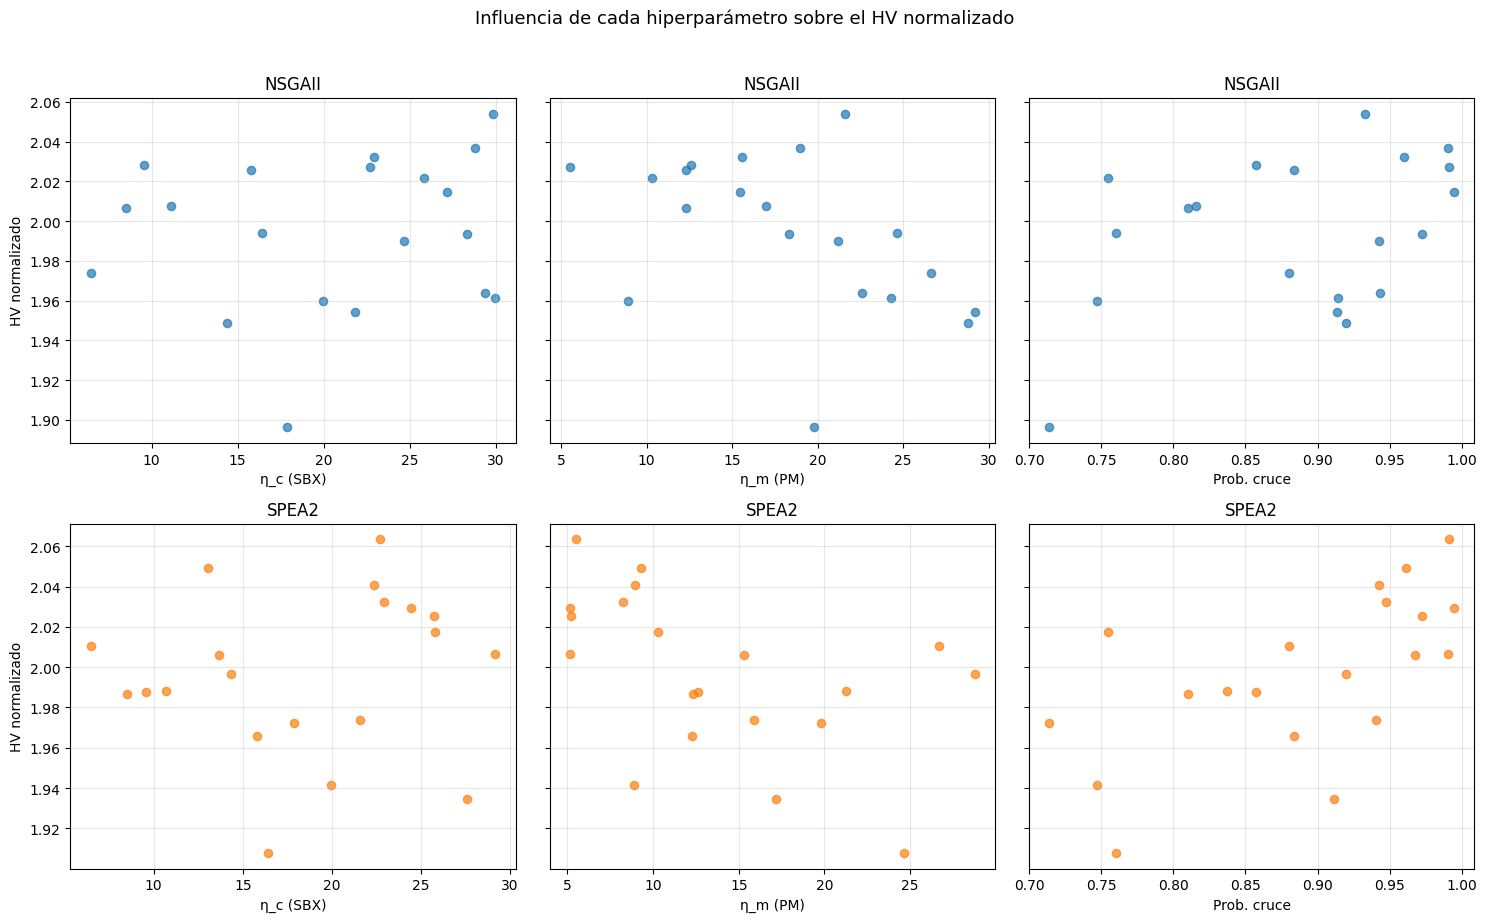

In [18]:
# ============================================================
#  SENSIBILIDAD: HV normalizado vs cada hiperparámetro (continuo)
# ============================================================
hp_params = ['eta_c', 'eta_m', 'crossover_prob']
hp_labels = ['η_c (SBX)', 'η_m (PM)', 'Prob. cruce']
algorithms = list(df['algorithm'].unique())
colors = {'NSGAII': '#1f77b4', 'SPEA2': '#ff7f0e'}

fig, axes = plt.subplots(len(algorithms), len(hp_params),
                         figsize=(15, 4.5 * len(algorithms)), sharey='row')
if len(algorithms) == 1:
    axes = axes.reshape(1, -1)

for row, algo in enumerate(algorithms):
    da = df[df['algorithm'] == algo]
    for col, (p, lbl) in enumerate(zip(hp_params, hp_labels)):
        ax = axes[row, col]
        ax.scatter(da[p], da['hv_norm'], color=colors.get(algo, 'gray'), alpha=0.7, s=35)
        ax.set_xlabel(lbl); ax.set_title(f'{algo}')
        if col == 0:
            ax.set_ylabel('HV normalizado')
        ax.grid(alpha=0.3)
plt.suptitle('Influencia de cada hiperparámetro sobre el HV normalizado', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

Parece que para SPEA2, hay una relación positiva entre HV y la probabilidad de cruce. De hecho, la búsqueda de mejores hiperparámetros ha seleccionado p_c=0.991 para SPEA2, mientras que para NSGA-II p_c=0.933. En general, en ningún caso hay ninguna relación clara y teniendo tan pocos ejemplares tampoco podemos afirmar nada con total seguridad.

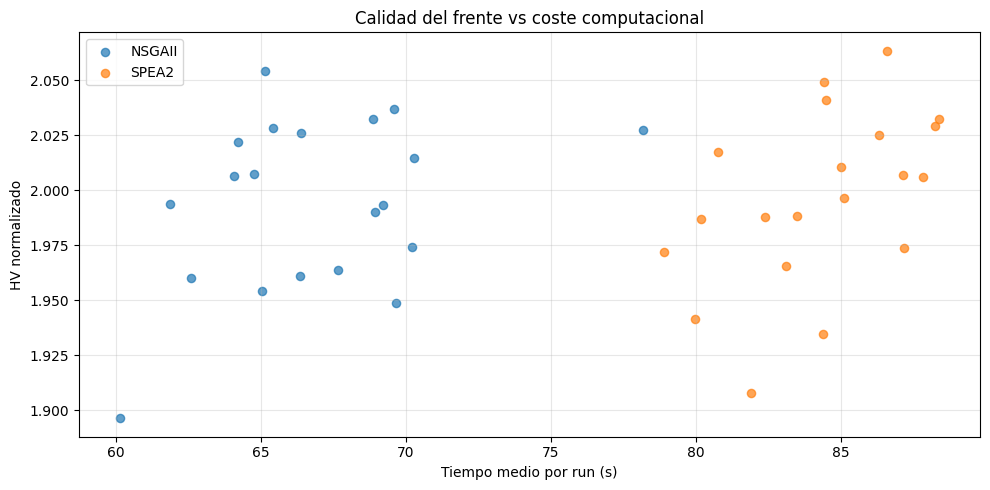

In [19]:
# ============================================================
#  COMPARATIVA NSGA-II vs SPEA2: HV normalizado vs tiempo
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for algo in algorithms:
    da = df[df['algorithm'] == algo].sort_values('elapsed_mean_s')
    ax.scatter(da['elapsed_mean_s'], da['hv_norm'], label=algo,
               color=colors.get(algo, 'gray'), alpha=0.7, s=35)
ax.set_xlabel('Tiempo medio por run (s)'); ax.set_ylabel('HV normalizado')
ax.set_title('Calidad del frente vs coste computacional'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

La mayor diferencia es el tiempo, SPEA2 tarda más tiempo.

## 11. Frentes de Pareto finales y comparación

In [20]:
pareto_fronts = {
    'NSGAII': front,
    'SPEA2' : front_spea2,
}

for algo_name, fr in pareto_fronts.items():
    fa = np.array([s.objectives for s in fr])
    print(f'{algo_name}: {len(fr)} soluciones no dominadas | '
          f'coste [{fa[:, 0].min():.2f}, {fa[:, 0].max():.2f}] € | '
          f'energia red [{fa[:, 1].min():.1f}, {fa[:, 1].max():.1f}] kWh')

NSGAII: 41 soluciones no dominadas | coste [1980.77, 1988.08] € | energia red [3952.3, 4007.6] kWh
SPEA2: 55 soluciones no dominadas | coste [1966.74, 1979.83] € | energia red [3937.3, 4251.7] kWh


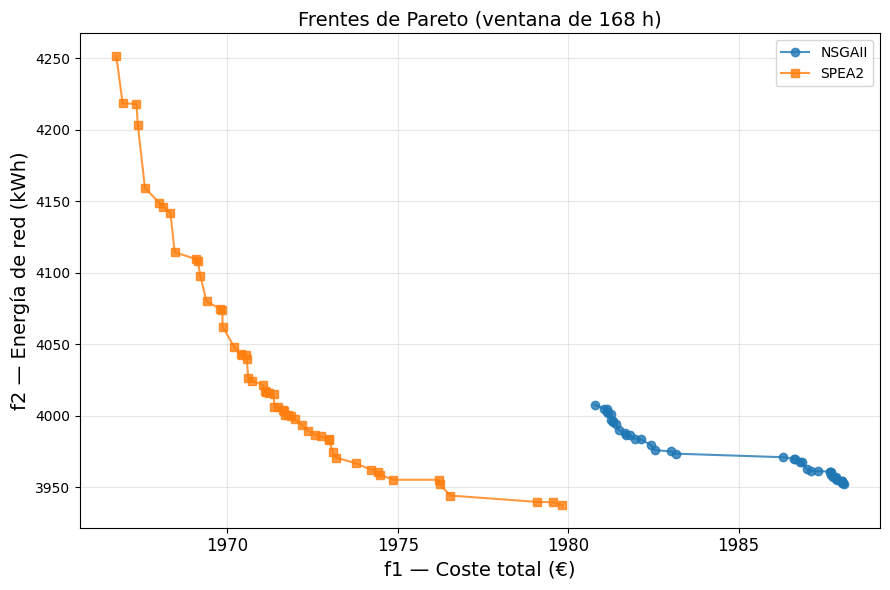

In [21]:
# ============================================================
#  FRENTES DE PARETO SUPERPUESTOS
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))
colors_front = {'NSGAII': '#1f77b4', 'SPEA2': '#ff7f0e'}
markers      = {'NSGAII': 'o',       'SPEA2': 's'}

for algo_name, front in pareto_fronts.items():
    f1 = [s.objectives[0] for s in front]   # coste
    f2 = [s.objectives[1] for s in front]   # energía de red
    order = sorted(range(len(f1)), key=lambda i: f1[i])
    ax.plot([f1[i] for i in order], [f2[i] for i in order],
            marker=markers.get(algo_name, 'o'), linestyle='-',
            color=colors_front.get(algo_name, 'gray'), label=algo_name, alpha=0.8)

ax.set_xlabel('f1 — Coste total (€)', fontsize=14)
ax.set_ylabel('f2 — Energía de red (kWh)', fontsize=14)
ax.set_title(f'Frentes de Pareto (ventana de {T} h)', fontsize=14)
ax.legend(); ax.grid(alpha=0.3)
ax.tick_params(axis='x', labelsize=12)
plt.tight_layout(); plt.show()

El algoritmo SPEA2 tiene una convergencia mucho mejor. Consigue unos individuos mejores que NSGAII en cuanto al objetivo de reducir la energía consumida de la red. Pero más importante parece la mejora en la reducción del coste total; incluso el individuo con mayor coste del frente de pareto conseguido por SPEA2 obtiene un coste menor que el individuo "más barato" NSGAII.

In [19]:
# ============================================================
#  SOLUCIONES REPRESENTATIVAS DEL FRENTE
# ============================================================
def front_to_dataframe(front) -> pd.DataFrame:
    data = []
    for s in front:
        x  = np.asarray(s.variables, dtype=float)
        x1 = x[:T]; x2 = x[T:]
        data.append({
            'coste_eur'        : s.objectives[0],
            'energia_red_kwh'  : s.objectives[1],
            'energia_solar_kwh': float(x1.sum()),
            'energia_eolico_kwh': float(x2.sum()),
            'pct_renovable'    : 100.0 * float((x1.sum() + x2.sum()) / DEMAND.sum()),
        })
    d = pd.DataFrame(data)
    return d.sort_values('coste_eur').reset_index(drop=True) if not d.empty else d

def representative(df_f, label):
    if df_f.empty:
        return df_f
    idx_min_coste = df_f['coste_eur'].idxmin()
    idx_min_red   = df_f['energia_red_kwh'].idxmin()
    idx_mid       = len(df_f) // 2
    sel = df_f.loc[[idx_min_coste, idx_mid, idx_min_red]].copy()
    sel.index = ['Mínimo coste', 'Equilibrada', 'Mínima energía de red']
    return sel

for algo_name, front in pareto_fronts.items():
    print(f'\n=== {algo_name} ===')
    display(representative(front_to_dataframe(front), algo_name))


=== NSGAII ===


,coste_eur,energia_red_kwh,energia_solar_kwh,energia_eolico_kwh,pct_renovable
Mínimo coste,1980.774280,4007.574756,2999.189629,7237.920819,71.407555
Equilibrada,1986.308735,3970.856015,3003.442982,7272.157241,71.676036
Mínima energía de red,1988.078279,3952.275744,3011.615951,7282.068816,71.802182



=== SPEA2 ===


,coste_eur,energia_red_kwh,energia_solar_kwh,energia_eolico_kwh,pct_renovable
Mínimo coste,1966.744558,4251.738257,3019.302031,6962.091279,69.623836
Equilibrada,1971.357398,4015.196876,3032.772801,7183.415476,71.261616
Mínima energía de red,1979.831009,3937.250380,3092.515808,7229.054365,71.996693


## 12. Métricas de calidad

El frente óptimo de referencia para calcular las métricas la hemos generado de la siguiente manera:
* Partimos del frente real combinado (≈ SPEA2)
* tomamos los mejores en cada objetivo como extremos
* generamos K puntos a lo largo de la curva
* los desplazamos un margen hacia el origen para que quede por debajo de SPEA2

In [ ]:
from jmetal.core.quality_indicator import (
    HyperVolume, GenerationalDistance, InvertedGenerationalDistance, EpsilonIndicator)

def spread(front, reference_front):
    front = np.array(front); reference_front = np.array(reference_front)
    front = front[np.argsort(front[:, 0])]
    reference_front = reference_front[np.argsort(reference_front[:, 0])]
    d_f = np.linalg.norm(front[0]  - reference_front[0])
    d_l = np.linalg.norm(front[-1] - reference_front[-1])
    distances = np.linalg.norm(np.diff(front, axis=0), axis=1)
    if len(distances) == 0:
        return 0.0
    d_mean = np.mean(distances)
    return (d_f + d_l + np.sum(np.abs(distances - d_mean))) / (d_f + d_l + len(distances) * d_mean)

todas = list(pareto_fronts['NSGAII']) + list(pareto_fronts['SPEA2'])
real  = np.array([s.objectives for s in get_non_dominated_solutions(todas)])
real  = real[np.argsort(real[:, 0])]                          # ordenado por coste (f1)

K, MARGEN = 50, 0.02                                          # 50 puntos, 2% mejor que SPEA2
f1_grid = np.linspace(real[:, 0].min(), real[:, 0].max(), K)
f2_grid = np.interp(f1_grid, real[:, 0], real[:, 1])
reference_front_array = np.column_stack([f1_grid, f2_grid]) * (1 - MARGEN)

print('=' * 60)
print('MÉTRICAS DE CALIDAD — mejor configuración por algoritmo')
print(f'Punto de referencia HV: {REFERENCE_POINT}')
print(f'Frente óptimo sintético: {len(reference_front_array)} puntos')
print('=' * 60)

resumen = {}
for algo_name, front in pareto_fronts.items():
    fa  = np.array([s.objectives for s in front])
    hv  = HyperVolume(reference_point=REFERENCE_POINT.tolist())
    gd  = GenerationalDistance(reference_front=reference_front_array)
    igd = InvertedGenerationalDistance(reference_front=reference_front_array)
    eps = EpsilonIndicator(reference_front=reference_front_array)
    resumen[algo_name] = {
        'HV raw'        : hv.compute(fa),
        'HV normalizado': hv.compute(fa) / area_espacio,
        'GD'            : gd.compute(fa),
        'IGD'           : igd.compute(fa),
        'ε-Indicator'   : eps.compute(fa),
        'Spread'        : spread(fa, reference_front_array),
        'Nº soluciones' : len(front),
    }

dfm = pd.DataFrame(resumen).T
dfm.index.name = 'Algoritmo'
display(dfm.style
        .format('{:.6f}', subset=[c for c in dfm.columns if c != 'Nº soluciones'])
        .format('{:.6f}', subset=['GD', 'IGD', 'ε-Indicator'])
        .background_gradient(subset=['HV normalizado'], cmap='YlGn')
        .background_gradient(subset=['GD', 'IGD', 'ε-Indicator', 'Spread'], cmap='YlOrRd_r')
        .set_caption('Métricas de calidad del frente de Pareto'))

MÉTRICAS DE CALIDAD — mejor configuración por algoritmo
Punto de referencia HV: [ 2534.79769409 15769.78995207]
Frente óptimo sintético: 50 puntos


,HV raw,HV normalizado,GD,IGD,ε-Indicator,Spread,Nº soluciones
Algoritmo,,,,,,,
NSGAII,6547008.912539,2.261736,54.207844,12.548591,93.770372,0.954855,41.000000
SPEA2,6720508.080358,2.321674,44.953547,9.223978,78.745008,0.951395,55.000000


Acorde a lo que se ha visto anteriormente en las visualizaciones, las métricas reflejan la superioridad clara de SPEA2 frente a NSGAII. Las métricas de convergencia tanto de diversidad son mejores para SPEA2.